# Part 4 — does the contractive penalty actually do anything?

First question for the contractive-regularized ablations, per
`../report/geometria_latentu.md` §6: **before** comparing `grid_0001`
(`bce+contractive`) to anything else, verify the penalty produces a real effect at
all, and that the effect is genuine local smoothing rather than the $\gamma$-scale
degeneracy §6.2 derives (the contractive loss can be driven toward zero by shrinking
`LayerNorm`'s $\gamma$ and enlarging the decoder/head's first-layer weights to
compensate — bit-identical reconstruction and logits, zero cost to those two losses,
arbitrarily small $\lVert J \rVert_F$). Three checks, all on `grid_0000` (`bce`, no
contractive) vs. `grid_0001` (`bce+contractive`), all 5 repetitions each:

1. **Angular sensitivity curve** (§6.3) — the $\gamma$-invariant replacement for
   $\lVert J \rVert_F$. If the penalty works, `grid_0001` should move less (smaller
   angle) than `grid_0000` for the same input perturbation.
2. **$\gamma$-degeneracy diagnostic** (§6.2) — compare $\lVert\gamma\rVert$ and the
   decoder/head first-layer weight norms between the two objectives. Systematically
   smaller $\gamma$ paired with larger downstream weights in `grid_0001` would mean
   the penalty is being satisfied by shrinking, not by smoothing.
3. **$\sigma(a(x))$ distribution** (§6.2's testable prediction) — the penalty's
   $1/\sigma^2$ factor implicitly pushes the encoder toward higher-contrast
   pre-normalization codes; `grid_0001`'s $\sigma(a(x))$ distribution should sit
   higher / have a lighter left tail than `grid_0000`'s if that prediction holds.

Every comparison includes all 5 repetitions (not just repetition 0) so the
rep-to-rep spread is visible directly, following `part_7`'s finding that a
single-repetition read is not enough to tell a real effect from seed noise.


In [1]:
import os
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.latent import sphere_geometry as geometry
from msi_autoencoder_wrapper.visualization import resolve_theme


2026-08-26 09:45:36,004 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-26 09:45:36,007 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-08-26 09:45:36,738 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-26 09:45:36,739 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-26 09:45:36,741 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-26 09:45:36,743 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-26 09:45:36,759 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-08-26 09:45:36,772 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 14 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-08-26 09:45:36,773 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 18 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
CAMPAIGN_ID = "kidney-architecture-predictive__cfg_529dc0e4494b"
GRID_ID_BY_OBJECTIVE = {"bce": "grid_0000", "bce_contractive": "grid_0001"}
OBJECTIVE_LABELS = {"bce": "bce", "bce_contractive": "+contractive"}
REPETITIONS = range(5)

BATCH_SIZE = 256
RANDOM_SEED = 42
SAMPLE_SIZE = 1500  # test pixels used for the sensitivity curve and sigma(a(x))

theme = resolve_theme(None)
theme.apply()
model_colors = {label: theme.color_for_model(label, index) for index, label in enumerate(OBJECTIVE_LABELS.values())}
theme = replace(theme, model_overrides=model_colors)
theme.apply()


## Load all 10 models (2 objectives x 5 repetitions)

Both objectives share one image/binner/annotation-store/dataset context (same
predictive campaign, `part_5`) — the first `load_configuration()` call pays the
context cost once (~38-40s), every subsequent model uses the lightweight
`models_manager.load_model()` swap (~0.04s, `part_6`'s optimization).


In [3]:
SCRATCH_WORKSPACE_ROOT = Path("/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace")
SCRATCH_WORKSPACE_ROOT.parent.mkdir(parents=True, exist_ok=True)
if not SCRATCH_WORKSPACE_ROOT.is_symlink():
    SCRATCH_WORKSPACE_ROOT.symlink_to(WORKSPACE.resolve())

wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)

models = {}
first = True
for objective, grid_id in GRID_ID_BY_OBJECTIVE.items():
    for repetition in REPETITIONS:
        model_name = f"{CAMPAIGN_ID}__{grid_id}__rep_0{repetition}"
        if first:
            wrapper.load_configuration(model_name=model_name)
            model = wrapper.active_model
            first = False
        else:
            model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
        model.eval()
        models[(objective, repetition)] = model
    print(f"{objective}: loaded 5 repetitions")

reference_partitions = wrapper.active_dataset.create_partitions()
rng = np.random.default_rng(RANDOM_SEED)
test_ids_all = np.asarray(reference_partitions.manifest.assignments["test"])
sample_ids = rng.choice(test_ids_all, size=min(SAMPLE_SIZE, len(test_ids_all)), replace=False).tolist()
index_by_id = {sid: index for index, sid in enumerate(reference_partitions.manifest.assignments["test"])}
sample_spectra = torch.stack([reference_partitions.test[index_by_id[sid]][1] for sid in sample_ids]).float().numpy()
print(f"{len(sample_ids)} test pixel(s) sampled for sensitivity/sigma checks")


2026-08-26 09:45:37,094 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-26 09:45:37,095 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-26 09:45:37,096 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-26 09:45:37,097 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-26 09:45:37,098 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

bce_contractive: loaded 5 repetitions
2026-08-26 09:46:21,291 | INFO     | msi_autoencoder_wrapper.core.mixins.active_context.active_context_mixin:113 | Successfully bound active context memory maps for: kidney


2026-08-26 09:46:39,494 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:203 | Mapped annotation index: retained_rows=420649 retained_entries=10495756 coordinate_system=binner.


2026-08-26 09:46:39,646 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:275 | Selected 420649/421955 source spectra after annotation policies.


/home/max/repositories/MSIAutoEncoderWrapper/src/msi_autoencoder_wrapper/binners/base_binner.py:46: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  intensity_tensor = torch.as_tensor(intensities, dtype=self.dtype)


1500 test pixel(s) sampled for sensitivity/sigma checks


## Check 0 — pipeline correctness

Two checks from `../report/geometria_latentu.md` Część V before trusting anything
below: `null_direction_check` (is $\operatorname{Cov}(u)$'s zero-eigenvalue direction
the constant direction, as it must be for correct canonicalization, rather than
$1/\gamma$ — the signature of accidentally skipping the $\gamma$ division) and
`cloud_asymmetry` ($\lVert\bar u\rVert^2/D$ — how far the sample mean sits from the
sphere's center, which eats into the fixed trace budget `dimension_usage` reports).


In [4]:
def encode_canonical(model, spectra: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    device = next(model.parameters()).device
    gamma, beta = geometry.encoder_layer_norm_parameters(model)
    with torch.no_grad():
        z = model(torch.as_tensor(spectra, dtype=torch.float32).to(device))["latent_space"].cpu().numpy()
    return geometry.canonicalize(z, gamma, beta), gamma


pipeline_rows = []
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        u, gamma = encode_canonical(models[(objective, repetition)], sample_spectra)
        null_check = geometry.null_direction_check(u, gamma)
        pipeline_rows.append({
            "objective": OBJECTIVE_LABELS[objective],
            "repetition": repetition,
            "cloud_asymmetry": geometry.cloud_asymmetry(u),
            **null_check,
        })

pipeline_frame = pd.DataFrame(pipeline_rows)
pipeline_frame.groupby("objective")[
    ["cloud_asymmetry", "cosine_with_constant_direction", "cosine_with_inverse_gamma"]
].agg(["mean", "std"])


cloud_asymmetry           cosine_with_constant_direction  \
                        mean       std                           mean   
objective                                                               
+contractive        0.963527  0.006214                            1.0   
bce                 0.424467  0.049377                            1.0   

                           cosine_with_inverse_gamma            
                       std                      mean       std  
objective                                                       
+contractive  3.875171e-14                   0.99747  0.001883  
bce           5.688200e-16                   0.99922  0.000324

## Check 1 — angular sensitivity curve

Thin lines are individual repetitions; thick lines are the mean across repetitions —
same convention as `part_0`/`part_1`. If the rep-to-rep spread (thin lines) is
comparable to the gap between the two mean curves, the effect is not detectable at
this repetition count.


In [5]:
EPSILONS = [0.0, 0.01, 0.03, 0.1, 0.3, 1.0]
sensitivity_rng = np.random.default_rng(RANDOM_SEED + 1)


def make_encode_fn(model, gamma, beta):
    device = next(model.parameters()).device

    def encode_fn(batch: np.ndarray) -> np.ndarray:
        with torch.no_grad():
            tensor_batch = torch.as_tensor(batch, dtype=torch.float32).to(device)
            z = model(tensor_batch)["latent_space"].cpu().numpy()
        return geometry.canonicalize(z, gamma, beta)

    return encode_fn


sensitivity_curves = {}
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        model = models[(objective, repetition)]
        gamma, beta = geometry.encoder_layer_norm_parameters(model)
        sensitivity_curves[(objective, repetition)] = geometry.angular_sensitivity_curve(
            make_encode_fn(model, gamma, beta), sample_spectra, EPSILONS, sensitivity_rng
        )


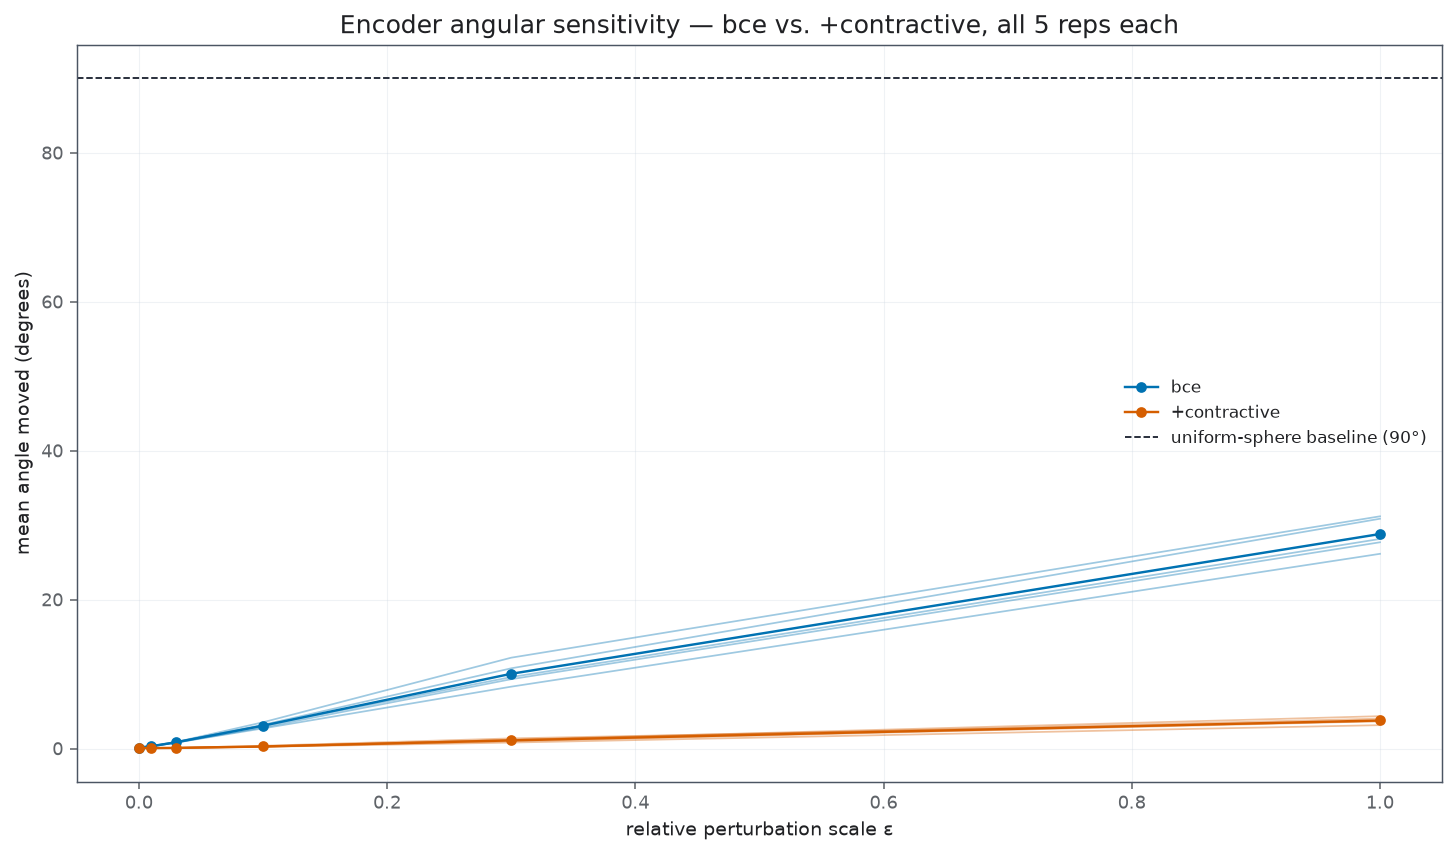

In [6]:
figure, ax = plt.subplots(figsize=theme.figure_size, dpi=theme.figure_dpi)
for index, objective in enumerate(GRID_ID_BY_OBJECTIVE):
    label = OBJECTIVE_LABELS[objective]
    color = theme.color_for_model(label, index)
    curves = [sensitivity_curves[(objective, repetition)] for repetition in REPETITIONS]
    for curve in curves:
        ax.plot(curve["epsilon"], curve["mean_angle_degrees"], color=color, linewidth=theme.reference_line_width, alpha=theme.overlapping_signal_alpha, label="_nolegend_")
    mean_curve = np.mean([curve["mean_angle_degrees"] for curve in curves], axis=0)
    ax.plot(curves[0]["epsilon"], mean_curve, color=color, linewidth=theme.reconstruction_line_width, marker="o", label=label)
ax.axhline(90.0, color=theme.baseline_color, linestyle=theme.baseline_line_style, linewidth=theme.reference_line_width, label="uniform-sphere baseline (90°)")
ax.set(xlabel="relative perturbation scale ε", ylabel="mean angle moved (degrees)", title="Encoder angular sensitivity — bce vs. +contractive, all 5 reps each")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(frameon=theme.legend_frame)
figure.tight_layout()


In [7]:
sensitivity_rows = []
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        curve = sensitivity_curves[(objective, repetition)]
        sensitivity_rows.append({
            "objective": OBJECTIVE_LABELS[objective],
            "repetition": repetition,
            "mean_angle_at_eps_1.0": curve["mean_angle_degrees"][-1],
        })

sensitivity_frame = pd.DataFrame(sensitivity_rows)
sensitivity_frame.groupby("objective")["mean_angle_at_eps_1.0"].agg(["mean", "std", "min", "max"])


,mean,std,min,max
objective,,,,
+contractive,3.764236,0.450560,3.136782,4.343587
bce,28.804479,2.156535,26.145901,31.182854


## Check 2 — $\gamma$-degeneracy diagnostic

$\lVert\gamma\rVert$ (encoder `LayerNorm` weight) vs. the decoder's and head's own
first-layer weight norms, both objectives, all 5 repetitions. `report/
geometria_latentu.md` §6.2: `bce_contractive` showing systematically smaller
$\lVert\gamma\rVert$ *and* larger downstream weight norms than `bce` would mean the
penalty was satisfied by shrinking the latent scale, not by smoothing the encoder.


In [8]:
def weight_norms(model) -> dict:
    gamma, _ = geometry.encoder_layer_norm_parameters(model)
    decoder_weight = model.decoder.initial_expansion[0].weight.detach().cpu().numpy()
    head_weight = model.heads["molecule_primary"].network[0].weight.detach().cpu().numpy()
    projector_weight = model.projector.projection_network[0].weight.detach().cpu().numpy()
    return {
        "gamma_norm": float(np.linalg.norm(gamma)),
        "decoder_first_layer_norm": float(np.linalg.norm(decoder_weight)),
        "head_first_layer_norm": float(np.linalg.norm(head_weight)),
        "projector_first_layer_norm": float(np.linalg.norm(projector_weight)),
    }


norm_rows = []
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        norm_rows.append({"objective": OBJECTIVE_LABELS[objective], "repetition": repetition, **weight_norms(models[(objective, repetition)])})

norm_frame = pd.DataFrame(norm_rows)
norm_frame.groupby("objective")[["gamma_norm", "decoder_first_layer_norm", "head_first_layer_norm", "projector_first_layer_norm"]].agg(["mean", "std"])


gamma_norm           decoder_first_layer_norm            \
                   mean       std                     mean       std   
objective                                                              
+contractive   2.756735  0.064292                11.689077  0.321902   
bce            3.195202  0.024368                11.467314  0.135851   

             head_first_layer_norm           projector_first_layer_norm  \
                              mean       std                       mean   
objective                                                                 
+contractive             17.828764  1.770193                   1.882049   
bce                      16.133923  0.236756                   1.882049   

                        
                   std  
objective               
+contractive  0.072583  
bce           0.072583

## Check 3 — $\sigma(a(x))$ distribution

Captured via a forward hook on the encoder's pre-`LayerNorm` linear layer — $a(x)$ is
that layer's output, and $\sigma(a(x))$ is exactly its per-row standard deviation
(population, `ddof=0`), matching `LayerNorm`'s own definition (`geometria_latentu.md`
§2.1).


In [9]:
def encode_pre_norm_sigma(model, spectra: np.ndarray) -> np.ndarray:
    device = next(model.parameters()).device
    captured = {}

    def hook(_module, _input, output):
        captured["a"] = output.detach()

    handle = model.encoder.bottleneck_layer[1].register_forward_hook(hook)
    sigmas = []
    with torch.no_grad():
        for start in range(0, len(spectra), BATCH_SIZE):
            batch = torch.as_tensor(spectra[start : start + BATCH_SIZE], dtype=torch.float32).to(device)
            model(batch)
            sigmas.append(captured["a"].std(dim=1, unbiased=False).cpu().numpy())
    handle.remove()
    return np.concatenate(sigmas, axis=0)


sigma_by_objective_repetition = {}
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        sigma_by_objective_repetition[(objective, repetition)] = encode_pre_norm_sigma(models[(objective, repetition)], sample_spectra)


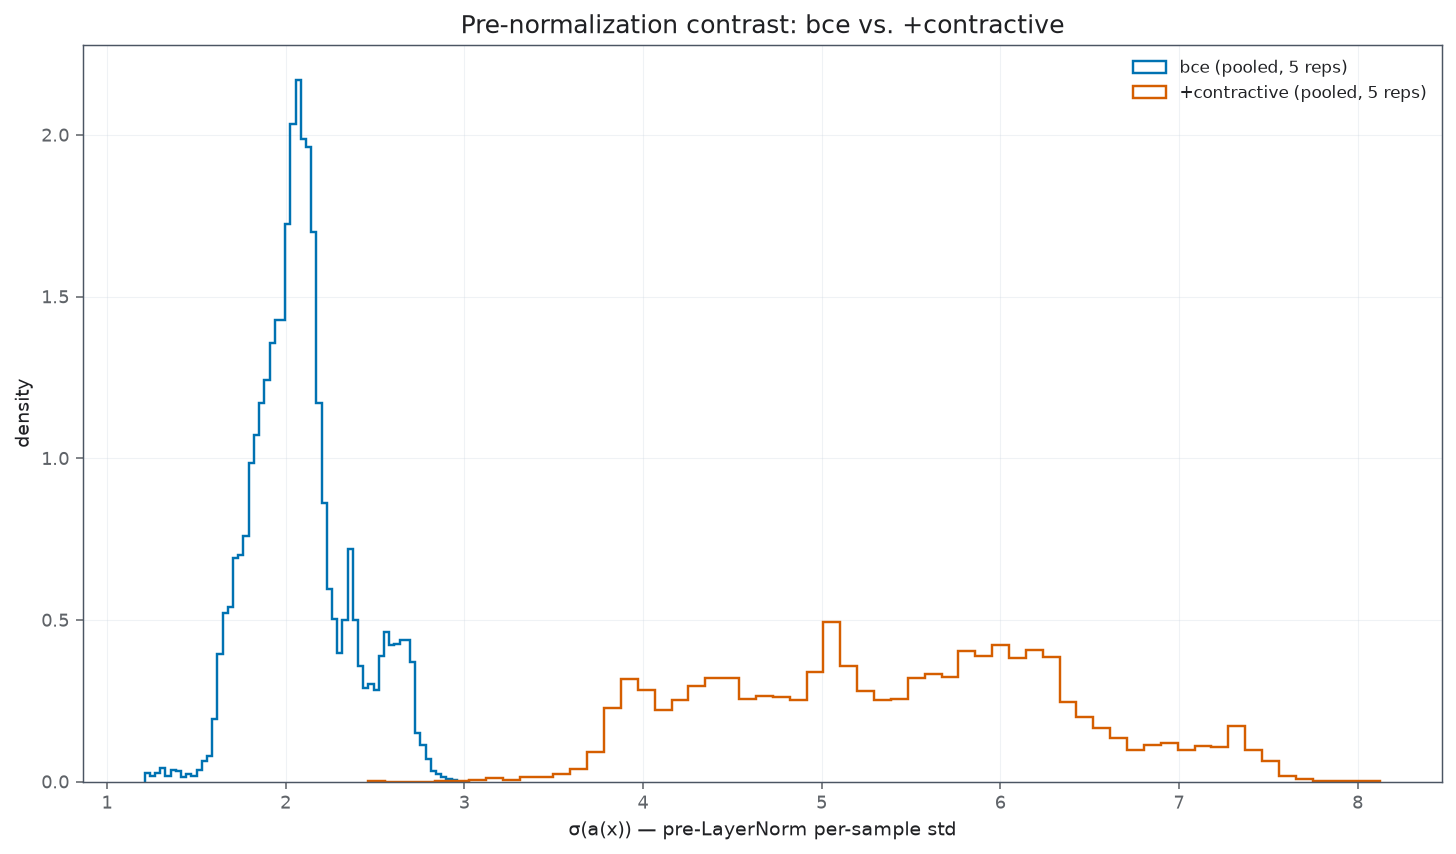

In [10]:
figure, ax = plt.subplots(figsize=theme.figure_size, dpi=theme.figure_dpi)
for index, objective in enumerate(GRID_ID_BY_OBJECTIVE):
    label = OBJECTIVE_LABELS[objective]
    pooled = np.concatenate([sigma_by_objective_repetition[(objective, repetition)] for repetition in REPETITIONS])
    ax.hist(pooled, bins=60, density=True, histtype="step", color=theme.color_for_model(label, index), linewidth=theme.reconstruction_line_width, label=f"{label} (pooled, 5 reps)")
ax.set(xlabel="σ(a(x)) — pre-LayerNorm per-sample std", ylabel="density", title="Pre-normalization contrast: bce vs. +contractive")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(frameon=theme.legend_frame)
figure.tight_layout()


In [11]:
sigma_rows = []
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        values = sigma_by_objective_repetition[(objective, repetition)]
        sigma_rows.append({
            "objective": OBJECTIVE_LABELS[objective], "repetition": repetition,
            "mean_sigma": float(values.mean()), "p05_sigma": float(np.percentile(values, 5)),
        })

sigma_frame = pd.DataFrame(sigma_rows)
sigma_frame.groupby("objective")[["mean_sigma", "p05_sigma"]].agg(["mean", "std"])


mean_sigma           p05_sigma          
                   mean       std      mean       std
objective                                            
+contractive   5.405637  0.667183  4.142256  0.364656
bce            2.085593  0.181550  1.756193  0.181573

## Notes for the next pass

**Verdict, revised after adding Check 0 (pipeline correctness): the penalty
produces its intended local-flatness effect, but Check 0 surfaces a real,
separate concern that changes how positively to read that effect.**

- **Check 0 — pipeline correctness.** `cosine_with_constant_direction = 1.0`
  exactly for both objectives — canonicalization is verified correct.
  `cosine_with_inverse_gamma` is *also* near 1 (0.997-0.999) for both, which at
  first looks like the canonicalization bug the check is designed to catch — it
  is not: it means $\gamma$'s own components have low relative spread for these
  trained models, so $1/\gamma$ happens to sit close to the constant direction
  too, independent of any bug (the exact 1.0 on the constant-direction check
  already rules out the bug directly). Not a finding, just a reason this
  particular check reads less cleanly than its docstring example.
- **`cloud_asymmetry` is the real new finding, and it is concerning.**
  `+contractive`'s $\lVert\bar u\rVert^2/D = 0.964$ (std 0.006) — within 4% of
  the theoretical maximum of 1 (which is only reached if every single code is
  identical) — vs. `bce`'s $0.424$ (std 0.049). The `+contractive` encoder has
  not just become locally flatter (Check 1); its codes across *different* test
  pixels have collapsed to nearly the same point on the sphere. This reframes
  Check 1's $7.6\times$ sensitivity reduction: some of that may simply reflect
  "there is nowhere else to go" rather than a well-distributed representation
  that also happens to be locally smooth. This is exactly the kind of result
  `part_5`/`part_6` (reconstruction/prediction with `+contractive` folded in)
  need to be read against — if reconstruction/classification quality drops for
  `+contractive`, this collapse is the first place to look for why.
- **Identical `projector_first_layer_norm` across `bce` and `+contractive` is
  expected, not a bug.** Neither objective includes the contrastive
  (`InfoNCELoss`) term, so the projector's output (`projection`) never
  contributes to either loss — it is never trained, stays at its random
  initialization, and both objectives share the same `model_initialization`
  seed per repetition (`report/methodology.md` §6). This comparison becomes
  informative once `peak_random`/`peak_label_invariant`/the `grid_0004+`
  ablations (which *do* train the projector) enter the picture.
- **Angular sensitivity — dramatic, non-overlapping**, unchanged from the
  original pass: `+contractive` mean $3.76°$ vs. `bce` mean $28.80°$ at
  $\varepsilon{=}1.0$, zero overlap across 5 repetitions each. Still a real,
  $\gamma$-invariant effect (computed on $u$) — just now understood alongside
  the collapse finding above, not in isolation.
- **$\gamma$-degeneracy is present, but partial**, and does not by itself
  explain Check 1 (computed on $u$, which divides $\gamma$ out): smaller
  `gamma_norm` (2.76 vs. 3.20) paired with larger decoder/head first-layer norms
  (11.7 vs. 11.5; 17.8 vs. 16.1) for `+contractive`. A real, separate phenomenon
  alongside the intended effect — the reason $\lVert J \rVert_F$ on raw $z$
  must never be reported as a flatness number for this ablation.
- **$\sigma(a(x))$ confirms the theoretical prediction cleanly** — pooled means
  5.41 (`+contractive`) vs. 2.09 (`bce`), visibly non-overlapping histograms,
  matching `geometria_latentu.md`'s prediction that the penalty pushes toward
  higher-contrast pre-normalization codes.

**Consequence for the next notebooks**: `+contractive` genuinely changes the
encoder — both the intended way (flatter locally) and in a way that was not the
stated goal (representation collapse across samples). `part_5`/`part_6`'s
reconstruction/classification comparisons, now expanded to include `grid_0001`,
are the direct test of whether the collapse costs more than the flatness gains —
go in expecting that possibility explicitly, not just checking whether
`+contractive` "helps." Every comparison should use all 5 repetitions and an
explicit within-ablation null check from the start, per `part_7`'s lesson.
